# Task 3: Correlation Analysis between News Sentiment and Stock Returns

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
import os
import glob

# Initialize VADER
analyzer = SentimentIntensityAnalyzer()

def get_sentiment(text):
    if not isinstance(text, str):
        return 0
    return analyzer.polarity_scores(text)['compound']

# Paths
data_dir = '../data/raw'
stock_files = glob.glob(os.path.join(data_dir, '*.csv'))
stock_files = [f for f in stock_files if 'raw_analyst_ratings' not in f]
news_file = os.path.join(data_dir, 'raw_analyst_ratings.csv')

print("Stock files:", stock_files)
print("News file:", news_file)

Stock files: ['../data/raw\\AAPL.csv', '../data/raw\\AMZN.csv', '../data/raw\\GOOG.csv', '../data/raw\\META.csv', '../data/raw\\NVDA.csv']
News file: ../data/raw\raw_analyst_ratings.csv


## 1. Load Stock Data and Calculate Daily Returns

In [2]:
stocks = {}
for file in stock_files:
    ticker = os.path.basename(file).split('.')[0]
    df = pd.read_csv(file)
    
    # Handle date column
    date_col = 'Date' if 'Date' in df.columns else 'date'
    df[date_col] = pd.to_datetime(df[date_col], utc=True).dt.date
    df.set_index(date_col, inplace=True)
    df.sort_index(inplace=True)
    
    # Calculate Daily Returns
    df['Daily_Return'] = df['Close'].pct_change()
    stocks[ticker] = df[['Daily_Return']]

# Combine returns into a single DataFrame for easier merging
all_returns = []
for ticker, df in stocks.items():
    temp_df = df.copy()
    temp_df['stock'] = ticker
    all_returns.append(temp_df)

returns_df = pd.concat(all_returns).reset_index()
returns_df.rename(columns={'index': 'date', 'Date': 'date'}, inplace=True)
print("Returns sample:")
print(returns_df.head())

Returns sample:
         date  Daily_Return stock
0  2009-01-02           NaN  AAPL
1  2009-01-05      0.042204  AAPL
2  2009-01-06     -0.016494  AAPL
3  2009-01-07     -0.021609  AAPL
4  2009-01-08      0.018570  AAPL


## 2. Load and Process News Sentiment

In [3]:
# Load news data - selecting only relevant columns to save memory
print("Loading news data...")
news_df = pd.read_csv(news_file, usecols=['headline', 'date', 'stock'])

# Filter for relevant stocks
relevant_stocks = list(stocks.keys())
news_df = news_df[news_df['stock'].isin(relevant_stocks)].copy()

# Parse news dates
print("Parsing news dates...")
def parse_date(date_str):
    try:
        return pd.to_datetime(date_str).date()
    except:
        try:
            return pd.to_datetime(date_str, utc=True).date()
        except:
            return None

news_df['date'] = news_df['date'].apply(parse_date)
news_df.dropna(subset=['date'], inplace=True)

# Calculate Sentiment
print("Calculating sentiment (this may take a minute)...")
news_df['sentiment'] = news_df['headline'].apply(get_sentiment)

# Aggregate sentiment by date and stock
daily_sentiment = news_df.groupby(['date', 'stock'])['sentiment'].mean().reset_index()

print("Daily sentiment sample:")
print(daily_sentiment.head())

Loading news data...


Parsing news dates...


Calculating sentiment (this may take a minute)...


Daily sentiment sample:
         date stock  sentiment
0  2011-03-03  NVDA    -0.5719
1  2011-03-07  NVDA    -0.2903
2  2011-03-08  NVDA     0.0234
3  2011-03-09  NVDA     0.0000
4  2011-03-10  NVDA     0.2023


## 3. Merge Data and Calculate Correlation

In [4]:
# Merge returns and sentiment
merged_df = pd.merge(returns_df, daily_sentiment, on=['date', 'stock'], how='inner')

print(f"Merged data shape: {merged_df.shape}")

# Calculate Correlation
correlation = merged_df.groupby('stock').apply(lambda x: x['Daily_Return'].corr(x['sentiment']))
print("\nPearson Correlation by Stock:")
print(correlation)

# Overall Correlation
overall_corr = merged_df['Daily_Return'].corr(merged_df['sentiment'])
print(f"\nOverall Correlation: {overall_corr:.4f}")

Merged data shape: (1566, 4)

Pearson Correlation by Stock:
stock
AAPL    0.123939
AMZN    0.166780
GOOG    0.189528
NVDA    0.214769
dtype: float64

Overall Correlation: 0.2050


## 4. Visualization

C:\Users\hp\AppData\Local\Temp\ipykernel_19516\328056220.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=correlation.index, y=correlation.values, palette='viridis')


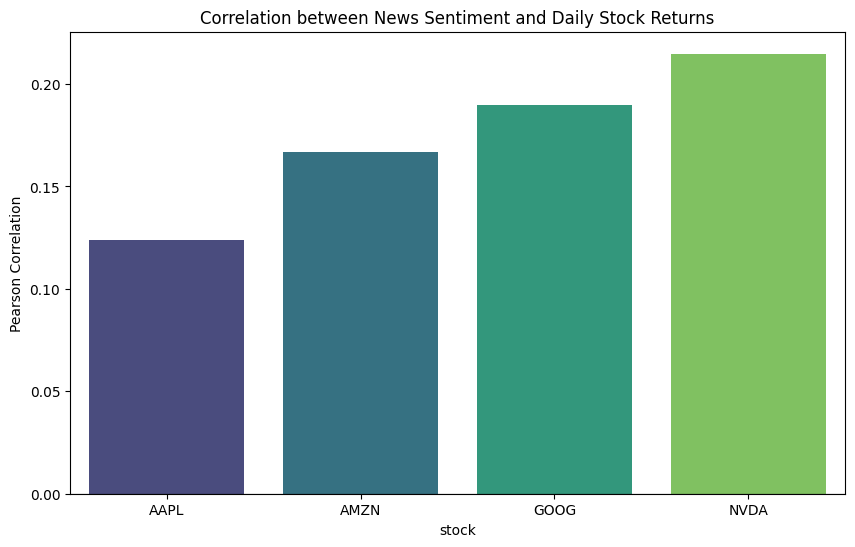

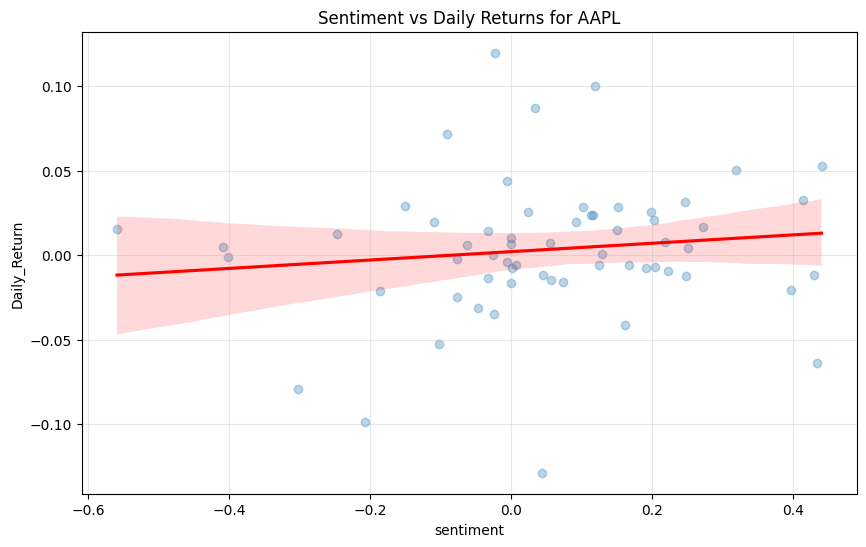

In [5]:
plt.figure(figsize=(10, 6))
sns.barplot(x=correlation.index, y=correlation.values, palette='viridis')
plt.title('Correlation between News Sentiment and Daily Stock Returns')
plt.ylabel('Pearson Correlation')
plt.axhline(0, color='black', linewidth=0.8)
plt.show()

# Scatter plot for one stock
ticker_to_plot = 'AAPL'
sample_plot = merged_df[merged_df['stock'] == ticker_to_plot]
plt.figure(figsize=(10, 6))
sns.regplot(data=sample_plot, x='sentiment', y='Daily_Return', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})
plt.title(f'Sentiment vs Daily Returns for {ticker_to_plot}')
plt.grid(True, alpha=0.3)
plt.show()